# DNS Challenge Read Speech — Interactive Tutorial

This notebook walks through the NeMo Curator audio pipeline for the DNS Challenge Read Speech dataset.

**What you'll learn:**
1. Download and inspect the dataset
2. Run each filter stage and examine intermediate outputs
3. Visualize quality score distributions
4. Tune thresholds to control quality vs. data retention

## 1. Setup

Install dependencies (skip if already installed):
```bash
uv sync --extra audio_cuda12
```

In [1]:
# Silence noisy logs BEFORE importing Curator / Ray / NeMo.
# Curator uses loguru; NeMo uses Python logging; Ray emits warnings + raylet stderr.
import json
import logging
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

os.environ.setdefault("LOGURU_LEVEL", "ERROR")
os.environ.setdefault("NEMO_LOG_LEVEL", "ERROR")

warnings.filterwarnings("ignore", message=r".*concurrency.*deprecated.*")
warnings.filterwarnings("ignore", message=r".*num_cpus and num_gpus.*experimental.*")
logging.getLogger("nemo_logger").setLevel(logging.ERROR)

RAW_DATA_DIR = "./dns_data"
RESULT_DIR = os.path.join(RAW_DATA_DIR, "result")
MAX_SAMPLES = 10


# Must match `AudioDataFilterStage` config in the pipeline cell below
BAND_FILTER_TARGET = "full_band"
UTMOS_THRESHOLD = 3.4
SIGMOS_OVRL_THRESHOLD = 3.5
SIGMOS_NOISE_THRESHOLD = 4.0

## 2. Download and Create Manifest

The `CreateInitialManifestReadSpeechStage` downloads the DNS Challenge dataset (~4.88 GB) and scans for WAV files.

In [ ]:
from nemo_curator.stages.audio.datasets.readspeech import CreateInitialManifestReadSpeechStage
from nemo_curator.tasks import EmptyTask

manifest_stage = CreateInitialManifestReadSpeechStage(
    raw_data_dir=RAW_DATA_DIR,
    max_samples=MAX_SAMPLES,
    auto_download=True,
)

audio_tasks = manifest_stage.process(EmptyTask)
print(f"Created {len(audio_tasks)} audio tasks")
print("\nSample entry:")
print(json.dumps(audio_tasks[0].data, indent=2))

## 3. Run the Full Pipeline

Build and run the pipeline with all filters enabled, using `MAX_SAMPLES` for a quick demo.

In [ ]:
import shutil

from nemo_curator.core.client import RayClient
from nemo_curator.pipeline import Pipeline
from nemo_curator.stages.audio import AudioDataFilterStage
from nemo_curator.stages.audio.datasets.readspeech import CreateInitialManifestReadSpeechStage
from nemo_curator.stages.audio.io.convert import AudioToDocumentStage
from nemo_curator.stages.text.io.writer import JsonlWriter

# Start a Ray cluster managed by Curator so Xenna's ray.init() finds exactly one cluster.
ray_client = RayClient()
ray_client.start()

if os.path.exists(RESULT_DIR):
    shutil.rmtree(RESULT_DIR)
os.makedirs(RESULT_DIR, exist_ok=True)

pipeline = Pipeline(
    name="readspeech_tutorial",
    description="DNS Challenge Read Speech tutorial pipeline",
)

pipeline.add_stage(
    CreateInitialManifestReadSpeechStage(
        raw_data_dir=RAW_DATA_DIR,
        max_samples=MAX_SAMPLES,
        auto_download=True,
        batch_size=1,
    )
)

pipeline.add_stage(
    AudioDataFilterStage(
        config={
            "mono_conversion": {"output_sample_rate": 48000},
            "vad": {"enable": True, "min_duration_sec": 2.0, "max_duration_sec": 60.0},
            "band_filter": {"enable": True, "band_value": BAND_FILTER_TARGET},
            "utmos": {"enable": True, "mos_threshold": UTMOS_THRESHOLD},
            "sigmos": {
                "enable": True,
                "noise_threshold": SIGMOS_NOISE_THRESHOLD,
                "ovrl_threshold": SIGMOS_OVRL_THRESHOLD,
            },
            "speaker_separation": {"enable": True, "exclude_overlaps": True, "min_duration": 0.8},
            "timestamp_mapper": {},
        }
    )
)

pipeline.add_stage(AudioToDocumentStage())
pipeline.add_stage(JsonlWriter(path=RESULT_DIR, write_kwargs={"force_ascii": False}))

print(pipeline.describe())

# Use the default executor (Xenna), matching pipeline.py CLI defaults.
pipeline.run()
print(f"Results written to {RESULT_DIR}")

## 4. Load and Inspect Results


> **Note on pass rate.** With `MAX_SAMPLES = 10` the pass rate is highly variable — which 10 files are sampled, and whether they survive VAD and SIGMOS thresholds, can vary significantly run-to-run. On the full 14,279-sample dataset the combined pass rate is **~23%**, dominated by SIGMOS filtering (`OVRL ≥ 3.5`, `NOISE ≥ 4.0`). Increase `MAX_SAMPLES` to 500+ to see a more representative and stable pass rate.

In [ ]:
from typing import Any


def load_jsonl_results(result_dir: str | Path) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    for f in sorted(Path(result_dir).glob("*.jsonl")):
        for line in f.read_text().strip().split("\n"):
            if line:
                records.append(json.loads(line))
    return records


results = load_jsonl_results(RESULT_DIR)
print(f"Total output records: {len(results)}")
print(f"Pass rate: {len(results)}/{MAX_SAMPLES} = {len(results)/MAX_SAMPLES*100:.1f}%")
print("\nSample output:")
print(json.dumps(results[0], indent=2) if results else "No results")


## 5. Visualize Quality Scores

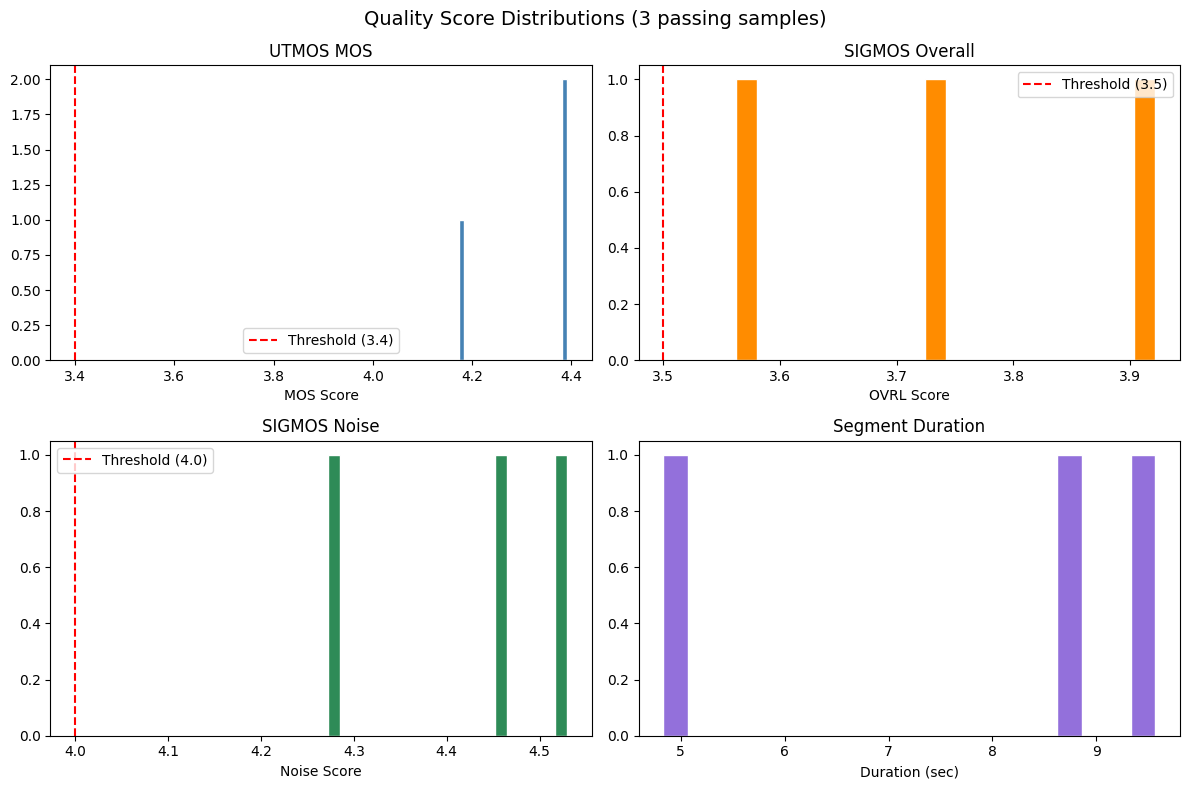

In [6]:
if not results:
    print("No results to visualize.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Quality Score Distributions ({len(results)} passing samples)", fontsize=14)

    # UTMOS MOS
    utmos_scores = [r["utmos_mos"] for r in results if "utmos_mos" in r]
    if utmos_scores:
        axes[0, 0].hist(utmos_scores, bins=20, color="steelblue", edgecolor="white")
        axes[0, 0].axvline(x=UTMOS_THRESHOLD, color="red", linestyle="--", label=f"Threshold ({UTMOS_THRESHOLD})")
        axes[0, 0].set_title("UTMOS MOS")
        axes[0, 0].set_xlabel("MOS Score")
        axes[0, 0].legend()

    # SIGMOS OVRL
    ovrl_scores = [r["sigmos_ovrl"] for r in results if "sigmos_ovrl" in r]
    if ovrl_scores:
        axes[0, 1].hist(ovrl_scores, bins=20, color="darkorange", edgecolor="white")
        axes[0, 1].axvline(
            x=SIGMOS_OVRL_THRESHOLD, color="red", linestyle="--", label=f"Threshold ({SIGMOS_OVRL_THRESHOLD})"
        )
        axes[0, 1].set_title("SIGMOS Overall")
        axes[0, 1].set_xlabel("OVRL Score")
        axes[0, 1].legend()

    # SIGMOS NOISE
    noise_scores = [r["sigmos_noise"] for r in results if "sigmos_noise" in r]
    if noise_scores:
        axes[1, 0].hist(noise_scores, bins=20, color="seagreen", edgecolor="white")
        axes[1, 0].axvline(
            x=SIGMOS_NOISE_THRESHOLD, color="red", linestyle="--", label=f"Threshold ({SIGMOS_NOISE_THRESHOLD})"
        )
        axes[1, 0].set_title("SIGMOS Noise")
        axes[1, 0].set_xlabel("Noise Score")
        axes[1, 0].legend()

    # Duration distribution
    durations = [r["duration_sec"] for r in results if "duration_sec" in r]
    if durations:
        axes[1, 1].hist(durations, bins=20, color="mediumpurple", edgecolor="white")
        axes[1, 1].set_title("Segment Duration")
        axes[1, 1].set_xlabel("Duration (sec)")

    plt.tight_layout()
    plt.show()

## 6. Band Classification Breakdown

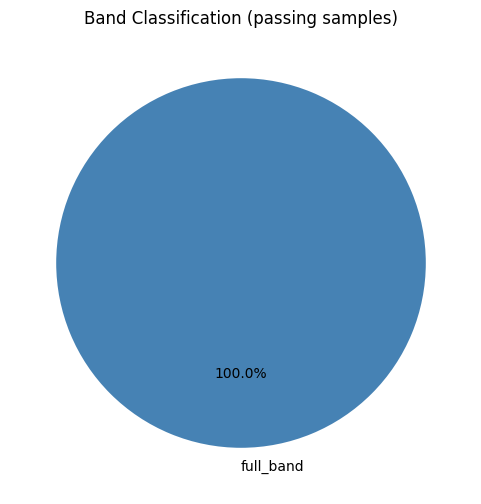

Band distribution: {np.str_('full_band'): np.int64(3)}


In [7]:
if results:
    bands = [r.get("band_prediction", "unknown") for r in results]
    unique, counts = np.unique(bands, return_counts=True)

    fig, ax = plt.subplots(figsize=(6, 6))
    colors = ["steelblue" if b == "full_band" else "coral" for b in unique]
    ax.pie(counts, labels=unique, autopct="%1.1f%%", colors=colors, startangle=90)
    ax.set_title("Band Classification (passing samples)")
    plt.show()

    print(f"Band distribution: {dict(zip(unique, counts, strict=True))}")


## 7. Speaker Distribution

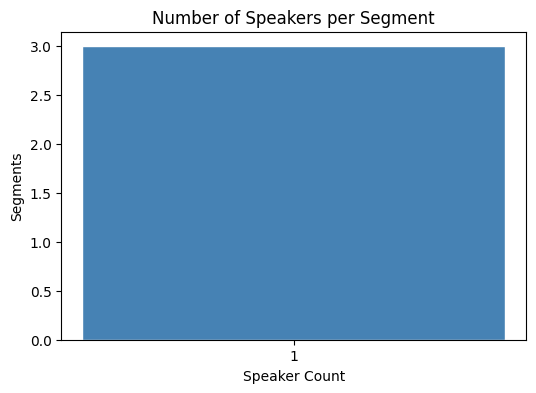

Speaker counts: {1: 3}


In [8]:
if results:
    speakers = [r.get("num_speakers", 0) for r in results]
    unique_spk, counts_spk = np.unique(speakers, return_counts=True)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar([str(s) for s in unique_spk], counts_spk, color="steelblue", edgecolor="white")
    ax.set_title("Number of Speakers per Segment")
    ax.set_xlabel("Speaker Count")
    ax.set_ylabel("Segments")
    plt.show()

    print(f"Speaker counts: {dict(zip(unique_spk.tolist(), counts_spk.tolist(), strict=True))}")

## 8. Threshold Sensitivity

See how changing UTMOS and SIGMOS OVRL thresholds affects data retention (computed against the scores stored in the JSONL output).

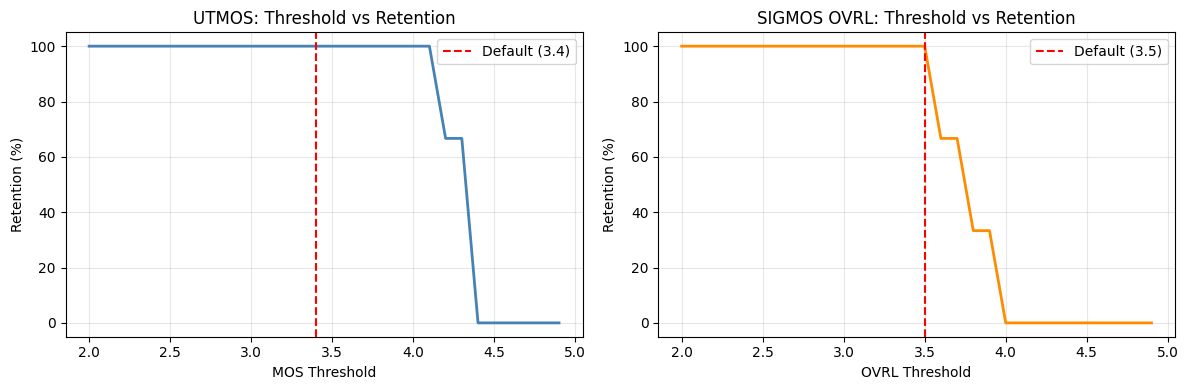

In [9]:
if results:
    utmos_scores = [r["utmos_mos"] for r in results if "utmos_mos" in r]
    ovrl_scores = [r["sigmos_ovrl"] for r in results if "sigmos_ovrl" in r]

    thresholds = np.arange(2.0, 5.0, 0.1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if utmos_scores:
        retention_utmos = [sum(1 for s in utmos_scores if s >= t) / len(utmos_scores) * 100 for t in thresholds]
        ax1.plot(thresholds, retention_utmos, color="steelblue", linewidth=2)
        ax1.axvline(x=UTMOS_THRESHOLD, color="red", linestyle="--", label=f"Default ({UTMOS_THRESHOLD})")
        ax1.set_title("UTMOS: Threshold vs Retention")
        ax1.set_xlabel("MOS Threshold")
        ax1.set_ylabel("Retention (%)")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

    if ovrl_scores:
        retention_ovrl = [sum(1 for s in ovrl_scores if s >= t) / len(ovrl_scores) * 100 for t in thresholds]
        ax2.plot(thresholds, retention_ovrl, color="darkorange", linewidth=2)
        ax2.axvline(x=SIGMOS_OVRL_THRESHOLD, color="red", linestyle="--", label=f"Default ({SIGMOS_OVRL_THRESHOLD})")
        ax2.set_title("SIGMOS OVRL: Threshold vs Retention")
        ax2.set_xlabel("OVRL Threshold")
        ax2.set_ylabel("Retention (%)")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## 9. Summary

This tutorial demonstrated:
- **Dataset download**: Auto-downloads DNS Challenge Read Speech (~4.88 GB, 14,279 files)
- **Pipeline stages**: Mono → VAD → Band Filter → UTMOS → SIGMOS → Speaker Separation
- **Quality filtering**: Default thresholds yield ~23% pass rate on the full dataset
- **Threshold tuning**: Visualize how thresholds affect data retention


In [ ]:
try:
    ray_client.stop()
except Exception as e:  # noqa: BLE001
    print(f"Error stopping Ray client: {e}")